# JAWAD HASSAN
# 2230-0035
# BS AI
# ML
# LAB 12
# Clustering

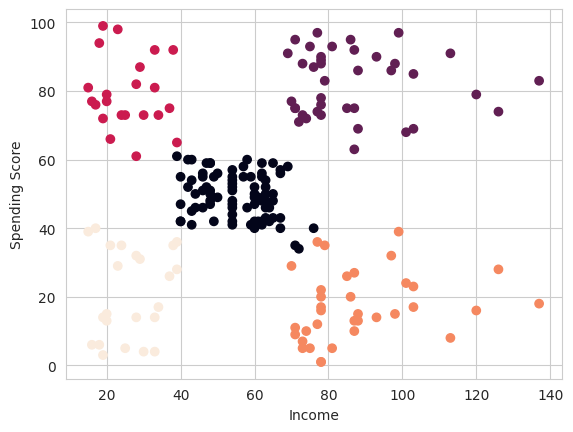

In [3]:
#kmeans
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

data = pd.read_csv("/Mall_Customers - Mall_Customers.csv")

X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)'],
    c=data['Cluster']
)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


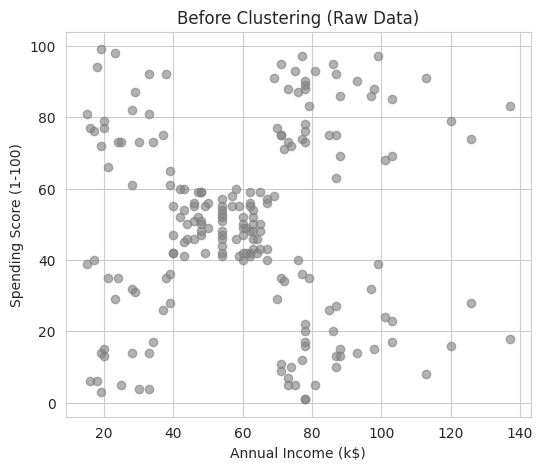

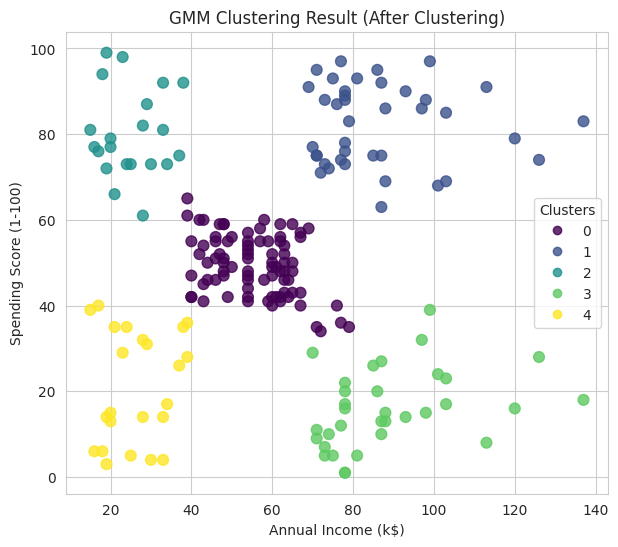

In [4]:
#gmm model
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("/Mall_Customers - Mall_Customers.csv")
print(df.head())
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#before
plt.figure(figsize=(6, 5))
plt.scatter(X["Annual Income (k$)"],
X["Spending Score (1-100)"],
c="gray", alpha=0.6)
plt.title("Before Clustering (Raw Data)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)
#Predicting cluster labels
labels = gmm.predict(X_scaled)
df["Cluster"] = labels
# after plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
X["Annual Income (k$)"],
X["Spending Score (1-100)"],
c=labels,
cmap="viridis",
s=60,
alpha=0.8
)
plt.title("GMM Clustering Result (After Clustering)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

   Domain  Mobile  Desktop  Web  IoT  Date_Difference  Expected Team Size  \
0       1       1        1    1    0              -10                  22   
1       1       1        1    1    0               20                  12   
2       1       1        1    1    0                0                  20   
3       1       1        1    1    0               10                  16   
4       1       1        1    0    0               37                   6   

   Expected Budget  Risk  
0           101450     1  
1            55000     3  
2           100000     1  
3            89000     2  
4            56000     3  


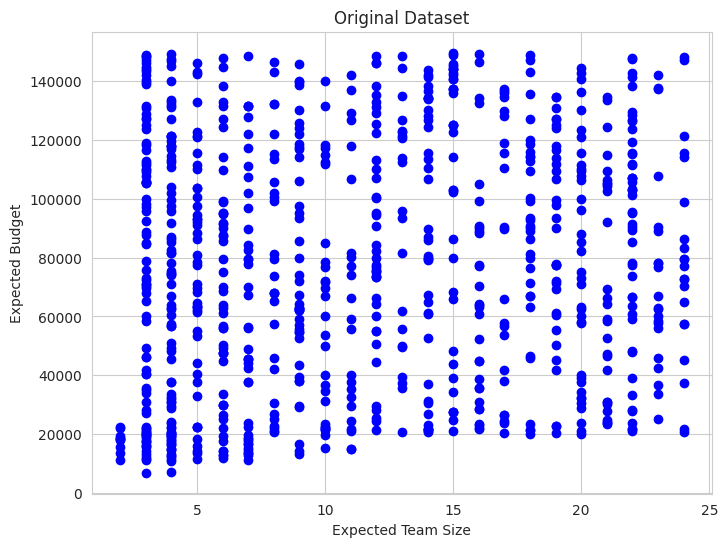

   Domain  Mobile  Desktop  Web  IoT  Date_Difference  Expected Team Size  \
0       1       1        1    1    0              -10                  22   
1       1       1        1    1    0               20                  12   
2       1       1        1    1    0                0                  20   
3       1       1        1    1    0               10                  16   
4       1       1        1    0    0               37                   6   

   Expected Budget  Risk  Cluster  
0           101450     1        0  
1            55000     3        1  
2           100000     1        0  
3            89000     2        0  
4            56000     3        1  


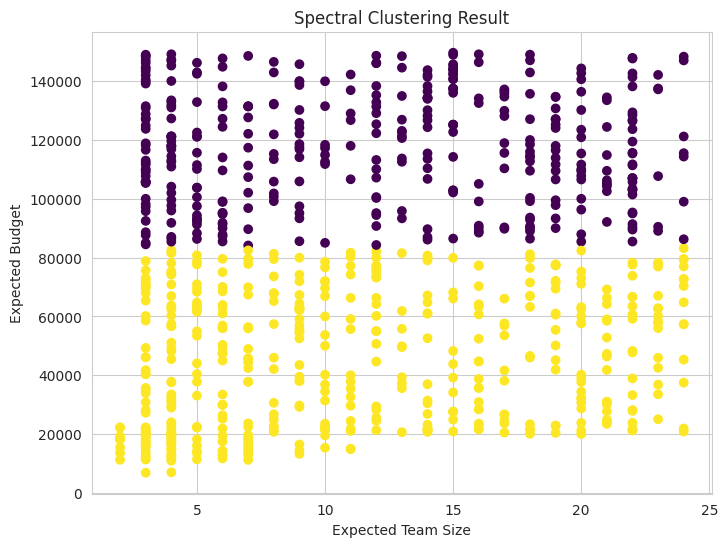

Clustered dataset saved


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering

df = pd.read_csv("/content/Project_Dataset_deelaka_Risk 3.csv")

print(df.head())

X = df[[
    "Expected Team Size",
    "Expected Budget"
]]

plt.figure(figsize=(8,6))

plt.scatter(
    X["Expected Team Size"],
    X["Expected Budget"],
    color='blue'
)

plt.title("Original Dataset")
plt.xlabel("Expected Team Size")
plt.ylabel("Expected Budget")
plt.grid(True)
plt.show()

spectral = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    random_state=42
)

clusters = spectral.fit_predict(X)

df["Cluster"] = clusters

print(df.head())

plt.figure(figsize=(8,6))

plt.scatter(
    X["Expected Team Size"],
    X["Expected Budget"],
    c=clusters,
    cmap='viridis'
)

plt.title("Spectral Clustering Result")
plt.xlabel("Expected Team Size")
plt.ylabel("Expected Budget")
plt.grid(True)
plt.show()

df.to_csv("Risk_clustered.csv", index=False)

print("Clustered dataset saved")

## Lab Task
## Perform GMM, Spectral Clustering, and K-means on the customer_segementation dataset that is attached on Google classroom…. Draw Scatter Plots and interpret results in your own words e.g which Clustering Algorithm performed well and why?

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


=== Clustering Performance (Silhouette Scores) ===
K-Means Score:      0.1807
GMM Score:          0.1741
Spectral Score:     0.1048



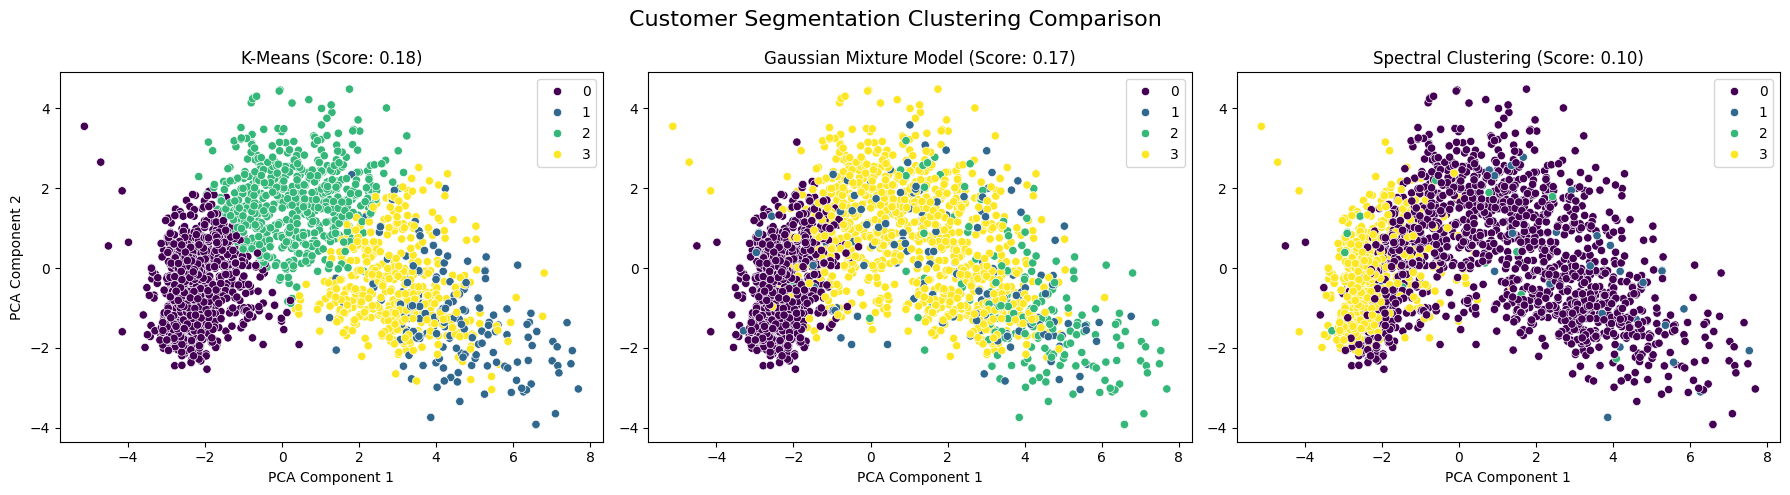

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# 1. Load the Dataset
# Make sure the file name matches exactly what you uploaded
df = pd.read_csv('/customer_segmentation2 - customer_segmentation2.csv')

# 2. Data Preprocessing
# Select only numeric columns for clustering and drop missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
X = df[numeric_cols].dropna()

# Standardize the features (Crucial for distance-based algorithms like KMeans and Spectral)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce dimensions to 2D using PCA for easy scatter plot visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Define the Number of Clusters (You can adjust this based on your data)
n_clusters = 4

# 4. Initialize the Algorithms
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
spectral = SpectralClustering(n_clusters=n_clusters, random_state=42, affinity='nearest_neighbors')

# 5. Fit and Predict
kmeans_labels = kmeans.fit_predict(X_scaled)
gmm_labels = gmm.fit_predict(X_scaled)
spectral_labels = spectral.fit_predict(X_scaled)

# 6. Calculate Silhouette Scores (Metric to evaluate performance)
# A score closer to 1 is better; closer to -1 is worse.
score_kmeans = silhouette_score(X_scaled, kmeans_labels)
score_gmm = silhouette_score(X_scaled, gmm_labels)
score_spectral = silhouette_score(X_scaled, spectral_labels)

print("=== Clustering Performance (Silhouette Scores) ===")
print(f"K-Means Score:      {score_kmeans:.4f}")
print(f"GMM Score:          {score_gmm:.4f}")
print(f"Spectral Score:     {score_spectral:.4f}\n")

# 7. Visualization: Draw Scatter Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Segmentation Clustering Comparison', fontsize=16)

# Plot K-Means
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', ax=axes[0], legend='full')
axes[0].set_title(f'K-Means (Score: {score_kmeans:.2f})')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

# Plot GMM
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=gmm_labels, palette='viridis', ax=axes[1], legend='full')
axes[1].set_title(f'Gaussian Mixture Model (Score: {score_gmm:.2f})')
axes[1].set_xlabel('PCA Component 1')

# Plot Spectral Clustering
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=spectral_labels, palette='viridis', ax=axes[2], legend='full')
axes[2].set_title(f'Spectral Clustering (Score: {score_spectral:.2f})')
axes[2].set_xlabel('PCA Component 1')

plt.tight_layout()
plt.show()

## kmeans give the best score so it performed best among all models.

## Lab Task
## Consider the below notebook and implement K-Means on Mall Customer Segmentation Dataset. Also you are required to explore the following Notebook to understand how EDA is done and what insights are concluded from each Visualization.

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB
None

First 5 rows:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0    Male   19                  15                      39
1    Male   21                  15                      81
2  Female   20                  16                       6
3  Female   23                  16                      77
4  Female   31                  17                      40


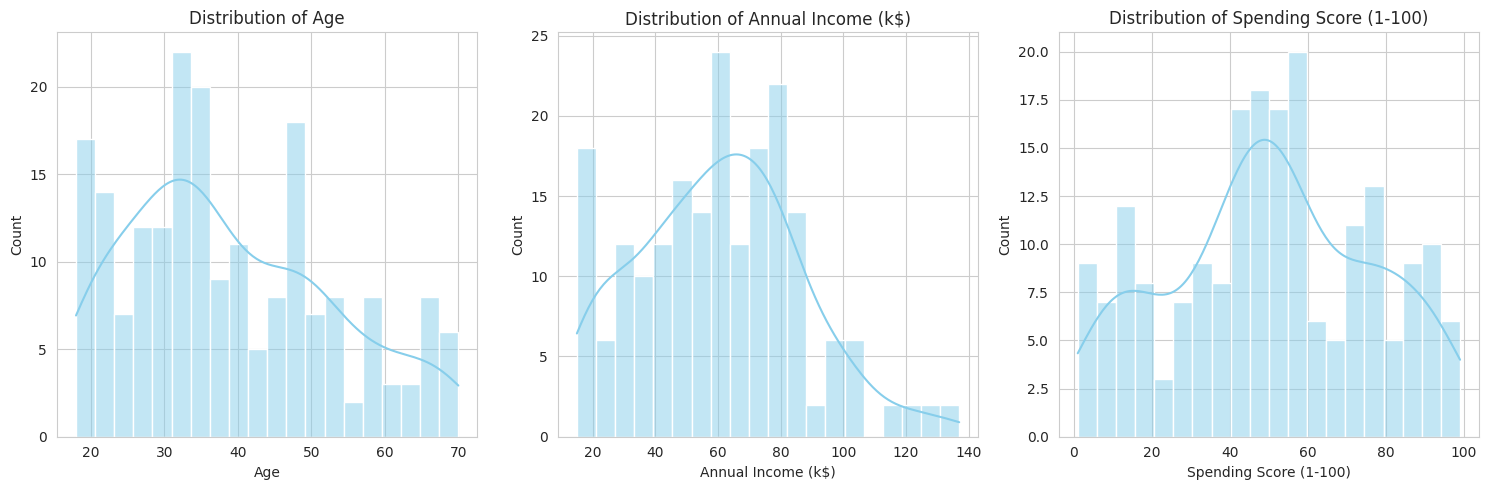

/tmp/ipykernel_14183/1691760162.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='pastel')


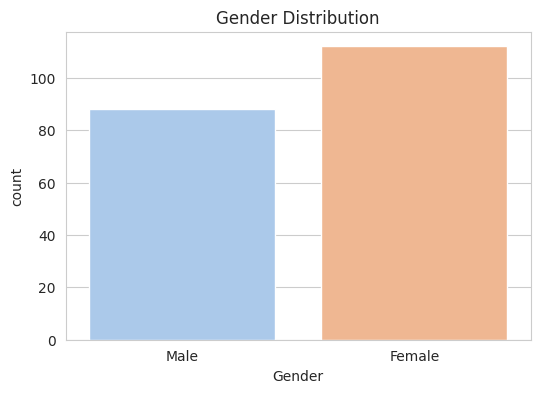

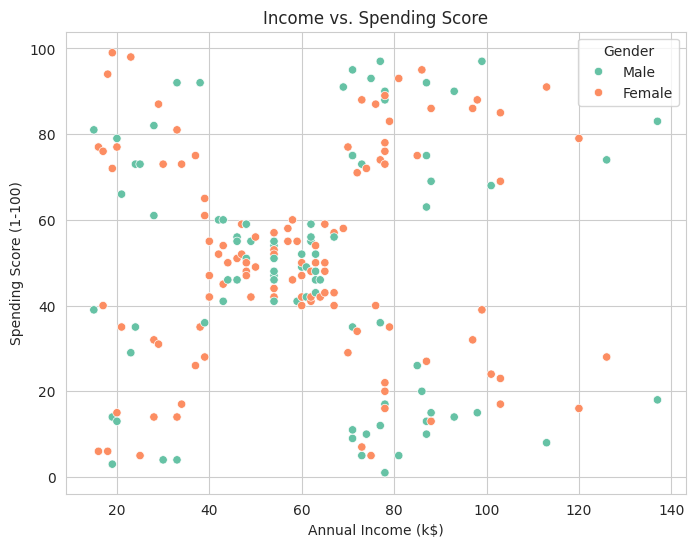

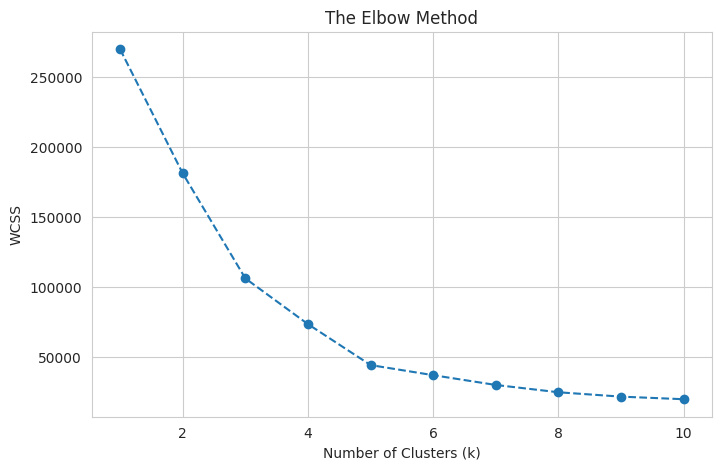

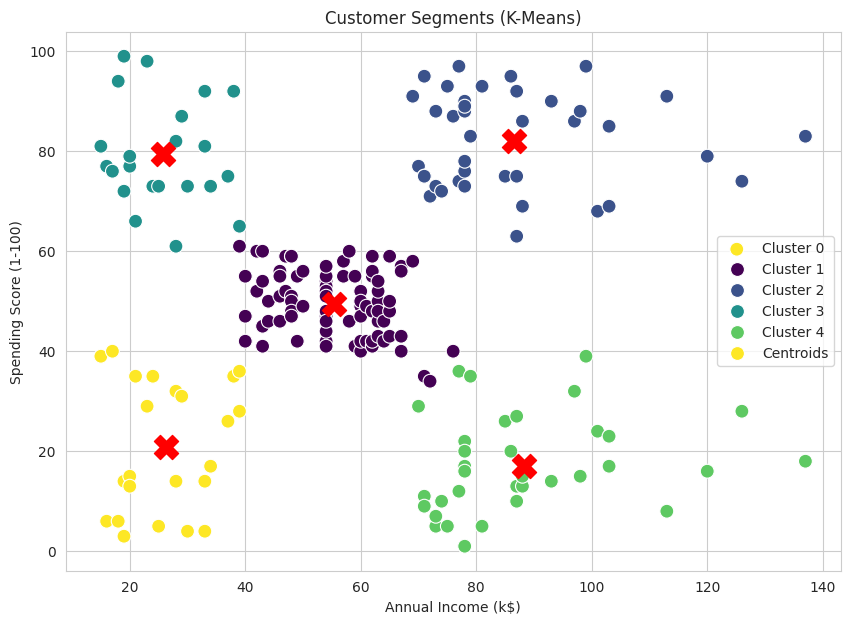

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Load the Dataset
# Ensure the file name matches your uploaded file
df = pd.read_csv('/Mall_Customers - Mall_Customers.csv')

# Drop CustomerID as it is not useful for EDA or clustering
df.drop('CustomerID', axis=1, inplace=True)

print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

# ==========================================
# 2. Exploratory Data Analysis (EDA)
# ==========================================
sns.set_style("whitegrid")

# Visualization 1: Distribution of Age, Income, and Spending Score
plt.figure(figsize=(15, 5))
for i, col in enumerate(['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Visualization 2: Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', palette='pastel')
plt.title('Gender Distribution')
plt.show()

# Visualization 3: Relationship between Income and Spending Score (Colored by Gender)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', palette='Set2')
plt.title('Income vs. Spending Score')
plt.show()

# ==========================================
# 3. K-Means Clustering Implementation
# ==========================================
# We will use 'Annual Income' and 'Spending Score' for clustering (creates a great 2D plot)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Step 3a: The Elbow Method to find the optimal number of clusters (k)
wcss = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Visualization 4: Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

# Step 3b: Fit K-Means with the optimal number of clusters (k=5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Visualization 5: Final Customer Segments
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=cluster_labels, palette='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='red', label='Centroids', marker='X')
plt.title('Customer Segments (K-Means)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Centroids'])
plt.show()

## The Exploratory Data Analysis reveals the mall is most popular among young adults, with the average customer earning between $50k and $80k.

## By utilizing the Elbow Method, we determined that dividing the customer base into exactly 5 distinct segments is the optimal approach.

## K-Means successfully separated these customers based on their income and spending habits, providing 5 clear target groups for future marketing campaigns.